# DC Motor data processing

In [263]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Load data from CSV file
csv_file = 'motor2.csv'
raw_df = pd.read_csv(csv_file) 

-792.84


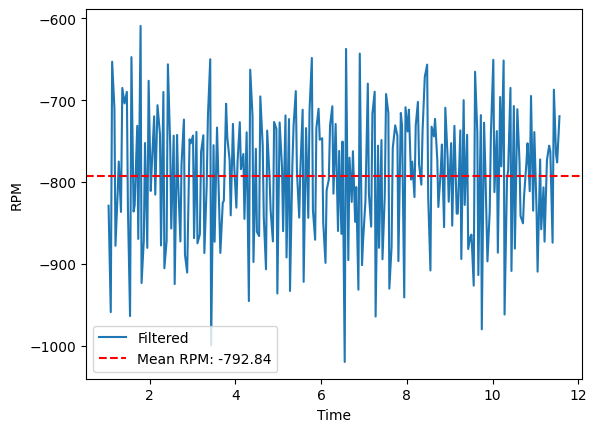

In [264]:
# Create DataFrame with rotor_position and time columns
rotor_data = pd.concat([raw_df.iloc[:, 125], raw_df.iloc[:, 129]], axis=1)
rotor_data.columns = ['rotor_position', 'Time']

# Calculate unfiltered angular velocity (RPM)
rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

# Remove positive velocities
rotor_data = rotor_data[rotor_data['RPM'] <= 0]

# Calculate mean and standard deviation of RPM
mean = rotor_data['RPM'].mean()
std_dev = rotor_data['RPM'].std()

# Define threshold for outliers
threshold = 3

# Filter out rows where RPM values are beyond the threshold
rotor_data = rotor_data[abs(rotor_data['RPM'] - mean) < threshold * std_dev]

# Create RPM filtered column
rotor_data['RPM filtered'] = rotor_data['RPM']

# Plot horizontal line for mean RPM
mean_rpm = rotor_data['RPM'].mean()

# Print mean velocity in RPM rounded to 2 decimal places
print(round(mean_rpm, 2))

# Plot filtered data
plt.plot(rotor_data['Time'], rotor_data['RPM filtered'], label='Filtered')
plt.axhline(y=mean_rpm, color='r', linestyle='--', label='Mean RPM: {:.2f}'.format(mean_rpm))
plt.xlabel('Time')
plt.ylabel('RPM')
plt.legend()
plt.show()

c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Eirik\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


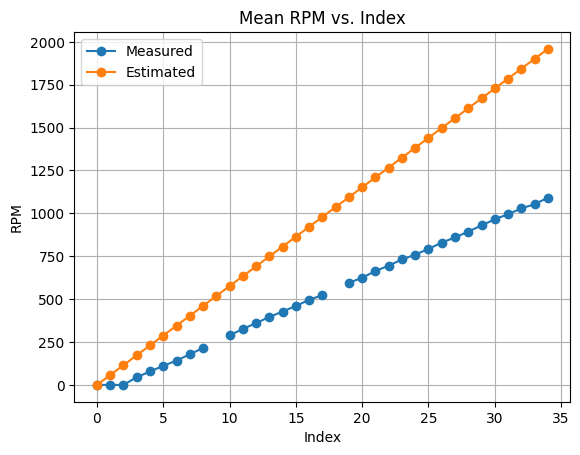

In [265]:
# Create a list of indices
indices = list(range(0, raw_df.shape[1], 5))

RPM = []
# Loop through the indices
for index in indices:
    # Create DataFrame with rotor_position and time columns
    rotor_data = pd.concat([raw_df.iloc[:, index], raw_df.iloc[:, (index+4)]], axis=1)
    rotor_data.columns = ['rotor_position', 'Time']

    # Calculate unfiltered angular velocity (RPM)
    rotor_data['RPM'] = rotor_data['rotor_position'].diff() / rotor_data['Time'].diff() * (60 / 360)

    # Remove positive velocities
    rotor_data = rotor_data[rotor_data['RPM'] <= 0]

    # Calculate mean and standard deviation of RPM
    mean = rotor_data['RPM'].mean()
    std_dev = rotor_data['RPM'].std()

    # Define threshold for outliers
    threshold = 3

    # Filter out rows where RPM values are beyond the threshold
    rotor_data = rotor_data[abs(rotor_data['RPM'] - mean) < threshold * std_dev]

    # Create RPM filtered column
    rotor_data['RPM filtered'] = rotor_data['RPM']

    # Plot horizontal line for mean RPM
    mean_rpm = rotor_data['RPM filtered'].mean()

    RPM.append(mean_rpm)

RPM = np.array(RPM)*(-1)

# Assuming RPM list is already populated
plt.plot(RPM, marker='o', label="Measured")
plt.plot(y, marker='o', label="Estimated")
plt.xlabel('Index')
plt.ylabel('RPM')
plt.title('Mean RPM vs. Index')
plt.legend()
plt.grid(True)
plt.show()